In [13]:
import subprocess
from pathlib import Path

repo_dir = Path(".")  # или полный путь к tda-2026

result = subprocess.run(
    ["julia", "embedding_quality_comparison.jl"],
    cwd=repo_dir,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Р СЏРґРѕРІ РІ ACF+FNN: 31
Р СЏРґРѕРІ РІ Uzal РїРѕСЃР»Рµ С„РёР»СЊС‚СЂР°С†РёРё Рё СѓРґР°Р»РµРЅРёСЏ РґСѓР±Р»РµР№: 27
Р’СЃРµРіРѕ СЃС‚СЂРѕРє РїР°СЂР°РјРµС‚СЂРѕРІ: 58
РљРѕР»РёС‡РµСЃС‚РІРѕ РєРѕР»РѕРЅРѕРє РІ data: 32
Р СЏРґС‹ РёР· ACF+FNN, РєРѕС‚РѕСЂС‹С… РЅРµС‚ РІ Uzal: ["Lab1_G3_РљРѕРєСЃРѕРІР°РЅРёРµ", "Lab1_G3_РўСѓСЂР±РёРЅР°_Р“Р“", "Lab1_TposleNag", "Lab1_TdoNag"]
Р“РѕС‚РѕРІРѕ: Lab1_G1_N3                acf_fnn  tau=  3 dim= 4 | NRMSE=1.1015 | noise_dist=0.0252
Р“РѕС‚РѕРІРѕ: Lab1_G2_FРЅ9               acf_fnn  tau=  3 dim= 5 | NRMSE=1.0473 | noise_dist=0.0224
Р“РѕС‚РѕРІРѕ: Lab1_G2_Fc3               acf_fnn  tau=  3 dim= 7 | NRMSE=0.8793 | noise_dist=0.0195
Р“РѕС‚РѕРІРѕ: Lab1_G1_N1                acf_fnn  tau= 26 dim= 5 | NRMSE=0.6379 | noise_dist=0.0276
Р“РѕС‚РѕРІРѕ: Lab1_G1_N2                acf_fnn  tau= 14 dim= 6 | NRMSE=0.6744 | noise_dist=0.0250
Р“РѕС‚РѕРІРѕ: Lab1_G2_3F2               acf_fnn  tau=  3 dim= 5 | NRMSE=0.9228 | noise_dist=0.0222
Р“РѕС‚РѕРІРѕ: Lab1_G1_T4СЃСЂ              acf

## Оценка качества вложения временного ряда

Для каждого временного ряда сравниваются два способа выбора параметров вложения: `ACF + FNN` и `Uzal`.  
Для каждого метода заданы параметры задержки $\tau$ и размерности вложения $m$.

### 1. Построение delay embedding

Пусть исходный временной ряд задан как:

$$
x_1, x_2, \dots, x_N
$$

Для заданных параметров $\tau$ и $m$ строится вектор задержек:

$$
X_t =
\left(
x_t,
x_{t+\tau},
x_{t+2\tau},
\dots,
x_{t+(m-1)\tau}
\right)
$$

где:

$$
t = 1, 2, \dots, N - (m-1)\tau - h
$$

Здесь:

- $\tau$ — задержка;
- $m$ — размерность вложения;
- $h$ — горизонт прогноза;
- $X_t$ — точка во вложенном фазовом пространстве.

Целевое значение для реконструкции динамики определяется как:

$$
y_t = x_{t+(m-1)\tau+h}
$$

В данной проверке используется $h=1$, то есть по текущему состоянию во вложенном пространстве прогнозируется следующее значение ряда после последней координаты embedding-вектора.

---

### 2. Ошибка реконструкции

Идея проверки состоит в том, что если вложение построено качественно, то близкие точки во вложенном пространстве должны иметь похожее будущее.

Для каждой тестовой точки $X_t$ находятся $k$ ближайших соседей в обучающей части:

$$
\mathcal{N}_k(X_t) =
\{X_{j_1}, X_{j_2}, \dots, X_{j_k}\}
$$

Прогноз строится как взвешенное среднее будущих значений соседей:

$$
\hat{y}_t =
\frac{
\sum\limits_{j \in \mathcal{N}_k(X_t)} w_j y_j
}{
\sum\limits_{j \in \mathcal{N}_k(X_t)} w_j
}
$$

где вес соседа обратно пропорционален расстоянию до него:

$$
w_j =
\frac{1}{\rho(X_t, X_j) + \varepsilon}
$$

Здесь:

$$
\rho(X_t, X_j) =
\|X_t - X_j\|_2
$$

а $\varepsilon$ — малое число, добавленное для предотвращения деления на ноль.

После этого считаются ошибки между истинным значением $y_t$ и прогнозом $\hat{y}_t$.

Абсолютная ошибка:

$$
e_t =
y_t - \hat{y}_t
$$

MAE:

$$
MAE =
\frac{1}{n}
\sum_{t=1}^{n}
|y_t - \hat{y}_t|
$$

RMSE:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}
(y_t - \hat{y}_t)^2
}
$$

Так как разные временные ряды могут иметь разные масштабы, дополнительно используется нормированная ошибка:

$$
NRMSE =
\frac{RMSE}{\operatorname{std}(y)}
$$

Чем меньше $MAE$, $RMSE$ и $NRMSE$, тем лучше вложение сохраняет локальную динамику временного ряда.

---

### 3. Добавление шума

Для оценки устойчивости вложения к шумам к исходному ряду добавляется искусственный шум:

$$
x_t^{noise} =
x_t + \eta_t
$$

где:

$$
\eta_t \sim \mathcal{N}(0, \sigma_{noise}^2)
$$

В коде стандартное отклонение шума задается относительно стандартного отклонения исходного ряда:

$$
\sigma_{noise}
=
\alpha \cdot \operatorname{std}(x)
$$

где $\alpha$ — уровень шума.  
В эксперименте используется:

$$
\alpha = 0.05
$$

То есть к ряду добавляется шум с уровнем примерно 5% от стандартного отклонения исходного ряда.

Для зашумленного ряда строится вложение с теми же параметрами $\tau$ и $m$:

$$
X_t^{noise} =
\left(
x_t^{noise},
x_{t+\tau}^{noise},
x_{t+2\tau}^{noise},
\dots,
x_{t+(m-1)\tau}^{noise}
\right)
$$

---

### 4. Ошибка смещения точек из-за шума

Первая шумовая метрика показывает, насколько сильно точки во вложенном пространстве смещаются после добавления шума.

Для каждой точки считается расстояние между исходным и зашумленным embedding-вектором:

$$
s_t =
\|X_t - X_t^{noise}\|_2
$$

Затем берется среднее смещение:

$$
\overline{s}
=
\frac{1}{n}
\sum_{t=1}^{n}
\|X_t - X_t^{noise}\|_2
$$

Чтобы не штрафовать вложения большей размерности только за то, что у них больше координат, смещение нормируется на стандартное отклонение ряда и корень из размерности:

$$
E_{shift}
=
\frac{
\frac{1}{n}
\sum\limits_{t=1}^{n}
\|X_t - X_t^{noise}\|_2
}{
\operatorname{std}(x)\sqrt{m}
}
$$

Чем меньше $E_{shift}$, тем устойчивее само положение точек во вложенном пространстве к шуму.

---

### 5. Искажение попарных расстояний

Вторая шумовая метрика показывает, насколько шум меняет геометрию вложенного пространства.

Для исходного вложения строится матрица попарных расстояний:

$$
D_{ij}
=
\|X_i - X_j\|_2
$$

Для зашумленного вложения строится аналогичная матрица:

$$
D_{ij}^{noise}
=
\|X_i^{noise} - X_j^{noise}\|_2
$$

Затем считается относительное искажение матрицы расстояний:

$$
E_D
=
\frac{
\|D - D^{noise}\|_F
}{
\|D\|_F
}
$$

где $\|\cdot\|_F$ — норма Фробениуса:

$$
\|D\|_F =
\sqrt{
\sum_i \sum_j D_{ij}^2
}
$$

Чем меньше $E_D$, тем лучше вложение сохраняет геометрическую структуру фазового пространства при добавлении шума.

---

### 6. Усреднение по нескольким шумовым запускам

Так как шум генерируется случайно, проверка проводится несколько раз.

Пусть количество запусков равно $R$. Тогда итоговая ошибка смещения точек:

$$
E_{shift}^{mean}
=
\frac{1}{R}
\sum_{r=1}^{R}
E_{shift}^{(r)}
$$

И итоговое искажение расстояний:

$$
E_D^{mean}
=
\frac{1}{R}
\sum_{r=1}^{R}
E_D^{(r)}
$$

В эксперименте используется:

$$
R = 10
$$

---

### 7. Нормализация метрик

Для итогового сравнения используются три метрики:

$$
NRMSE
$$

$$
E_{shift}^{mean}
$$

$$
E_D^{mean}
$$

Так как эти величины имеют разный масштаб, каждая метрика нормируется методом min-max:

$$
z_i =
\frac{
q_i - q_{min}
}{
q_{max} - q_{min}
}
$$

где:

- $q_i$ — значение метрики для конкретного вложения;
- $q_{min}$ — минимальное значение этой метрики среди всех рассматриваемых вложений;
- $q_{max}$ — максимальное значение этой метрики среди всех рассматриваемых вложений.

После такой нормализации все метрики приводятся к диапазону $[0, 1]$.

---

### 8. Итоговый quality score

Итоговое качество вложения считается как среднее значение трех нормированных ошибок:

$$
QualityScore =
\frac{
NRMSE_{norm}
+
E_{shift,norm}
+
E_{D,norm}
}{3}
$$

Чем меньше значение $QualityScore$, тем лучше считается вложение.

Меньшее значение означает, что вложение одновременно:

- лучше восстанавливает локальную динамику временного ряда;
- меньше смещается при добавлении шума;
- лучше сохраняет геометрию попарных расстояний в фазовом пространстве.

---

### 9. Интерпретация сравнения методов

Для каждого ряда сравниваются два значения:

$$
QualityScore_{ACF+FNN}
$$

и

$$
QualityScore_{Uzal}
$$

Если:

$$
QualityScore_{ACF+FNN}
<
QualityScore_{Uzal}
$$

то для данного ряда более качественным считается вложение, полученное методом `ACF + FNN`.

Если:

$$
QualityScore_{Uzal}
<
QualityScore_{ACF+FNN}
$$

то более качественным считается вложение, полученное методом `Uzal`.

Также можно рассматривать разность:

$$
\Delta Q =
QualityScore_{ACF+FNN}
-
QualityScore_{Uzal}
$$

Тогда:

$$
\Delta Q < 0
$$

означает, что лучше `ACF + FNN`, а

$$
\Delta Q > 0
$$

означает, что лучше `Uzal`.

Количество строк по методам:
method
acf_fnn    31
uzal       27
Name: count, dtype: int64

Количество уникальных рядов по методам:
method
acf_fnn    31
uzal       27
Name: column, dtype: int64

Дубли по column + method:


,column,method,count



Всего строк в исходном full: 58
Общих рядов, где есть оба метода: 27
Строк после фильтрации: 54

Количество строк по методам после фильтрации:
method
uzal       27
acf_fnn    27
Name: count, dtype: int64

Количество уникальных рядов по методам после фильтрации:
method
acf_fnn    27
uzal       27
Name: column, dtype: int64


,column,method,tau,dimension,uzal_cost,reconstruction_nrmse,noise_point_shift,noise_distance_distortion,quality_score
0,Lab1_G1_N1,acf_fnn,26,5,NaN,0.637889,0.047664,0.027562,0.271740
1,Lab1_G1_N1,uzal,98,4,1.028918,0.628692,0.047182,0.030479,0.230417
2,Lab1_G1_N2,acf_fnn,14,6,NaN,0.674377,0.048327,0.024952,0.339792
3,Lab1_G1_N2,uzal,67,5,1.014695,0.704848,0.047792,0.028373,0.302963
4,Lab1_G1_N3,acf_fnn,3,4,NaN,1.101515,0.047144,0.025241,0.296388
5,Lab1_G1_N3,uzal,27,3,0.838917,1.136125,0.046280,0.029027,0.225834
6,Lab1_G1_T1,acf_fnn,33,6,NaN,0.690670,0.048512,0.023891,0.358477
7,Lab1_G1_T1,uzal,93,5,-0.231622,0.907079,0.047741,0.024945,0.321827
8,Lab1_G1_T4ср,acf_fnn,51,5,NaN,0.675859,0.047728,0.028857,0.292426
9,Lab1_G1_T4ср,uzal,71,6,0.252611,0.900011,0.048188,0.026207,0.375504


,column,dimension_acf_fnn,dimension_uzal,noise_distance_distortion_acf_fnn,noise_distance_distortion_uzal,noise_point_shift_acf_fnn,noise_point_shift_uzal,quality_score_acf_fnn,quality_score_uzal,reconstruction_nrmse_acf_fnn,reconstruction_nrmse_uzal,tau_acf_fnn,tau_uzal,quality_score_diff_acf_fnn_minus_uzal,best_method
0,Lab1_G1_N1,5,4,0.027562,0.030479,0.047664,0.047182,0.271740,0.230417,0.637889,0.628692,26,98,0.041323,uzal
1,Lab1_G1_N2,6,5,0.024952,0.028373,0.048327,0.047792,0.339792,0.302963,0.674377,0.704848,14,67,0.036829,uzal
2,Lab1_G1_N3,4,3,0.025241,0.029027,0.047144,0.046280,0.296388,0.225834,1.101515,1.136125,3,27,0.070554,uzal
3,Lab1_G1_T1,6,5,0.023891,0.024945,0.048512,0.047741,0.358477,0.321827,0.690670,0.907079,33,93,0.036650,uzal
4,Lab1_G1_T4ср,5,6,0.028857,0.026207,0.047728,0.048188,0.292426,0.375504,0.675859,0.900011,51,71,-0.083077,acf_fnn
5,Lab1_G1_T600,8,7,0.019414,0.020048,0.048605,0.048482,0.366866,0.557155,0.785661,1.790096,37,99,-0.190289,acf_fnn
6,Lab1_G1_T607,3,12,0.031130,0.017371,0.046358,0.049213,0.175838,0.673191,0.793957,2.030031,14,72,-0.497353,acf_fnn
7,Lab1_G1_T638,7,6,0.022399,0.023132,0.048799,0.048221,0.360617,0.287815,0.578205,0.515195,31,22,0.072802,uzal
8,Lab1_G2_2F2,6,3,0.020461,0.029203,0.048125,0.046297,0.357773,0.212609,0.980341,1.056180,2,18,0.145164,uzal
9,Lab1_G2_3F2,5,4,0.022163,0.025686,0.047746,0.047093,0.312567,0.269683,0.922835,0.985860,3,10,0.042884,uzal


,wins
best_method,
uzal,17
acf_fnn,10


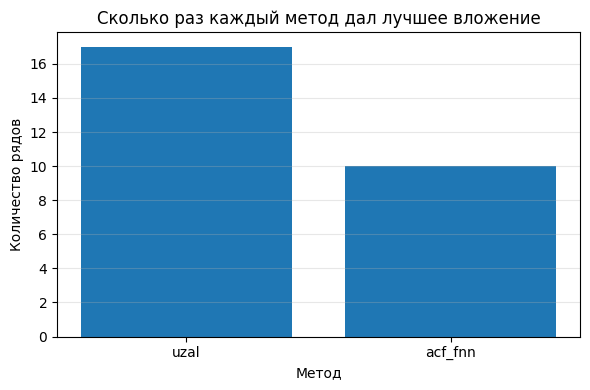

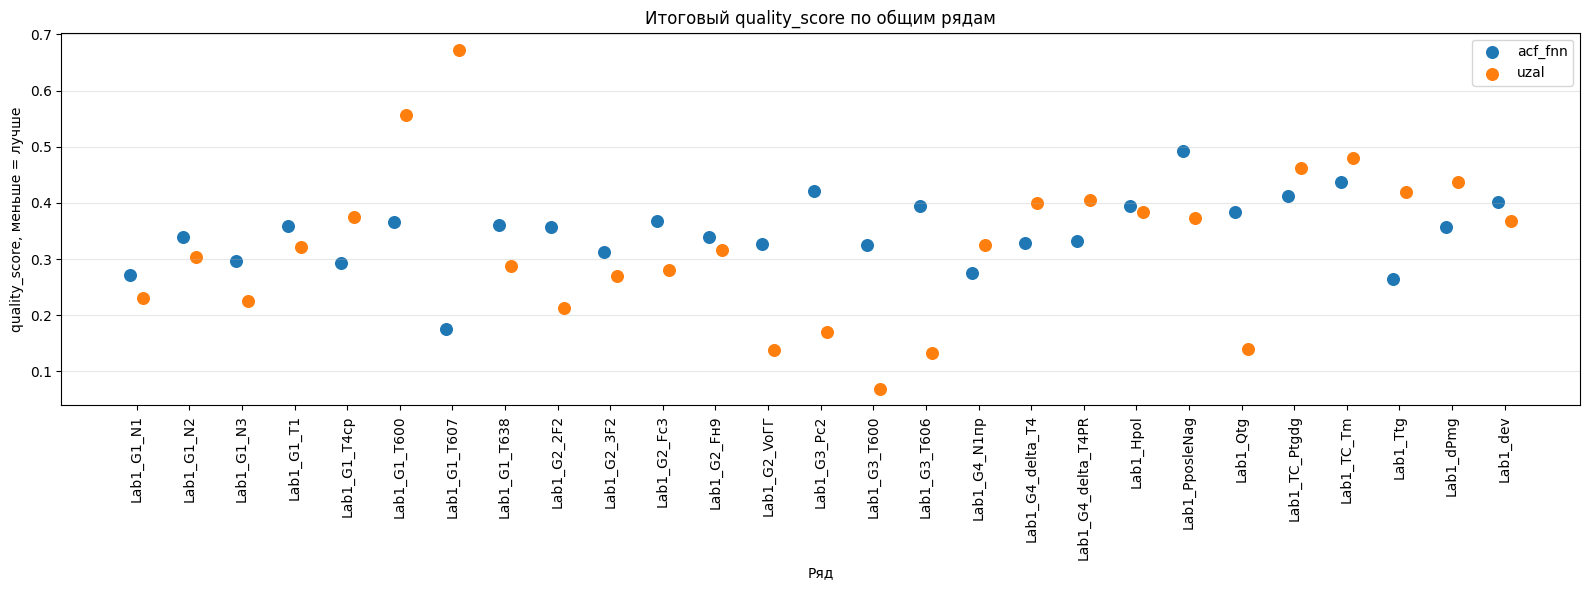

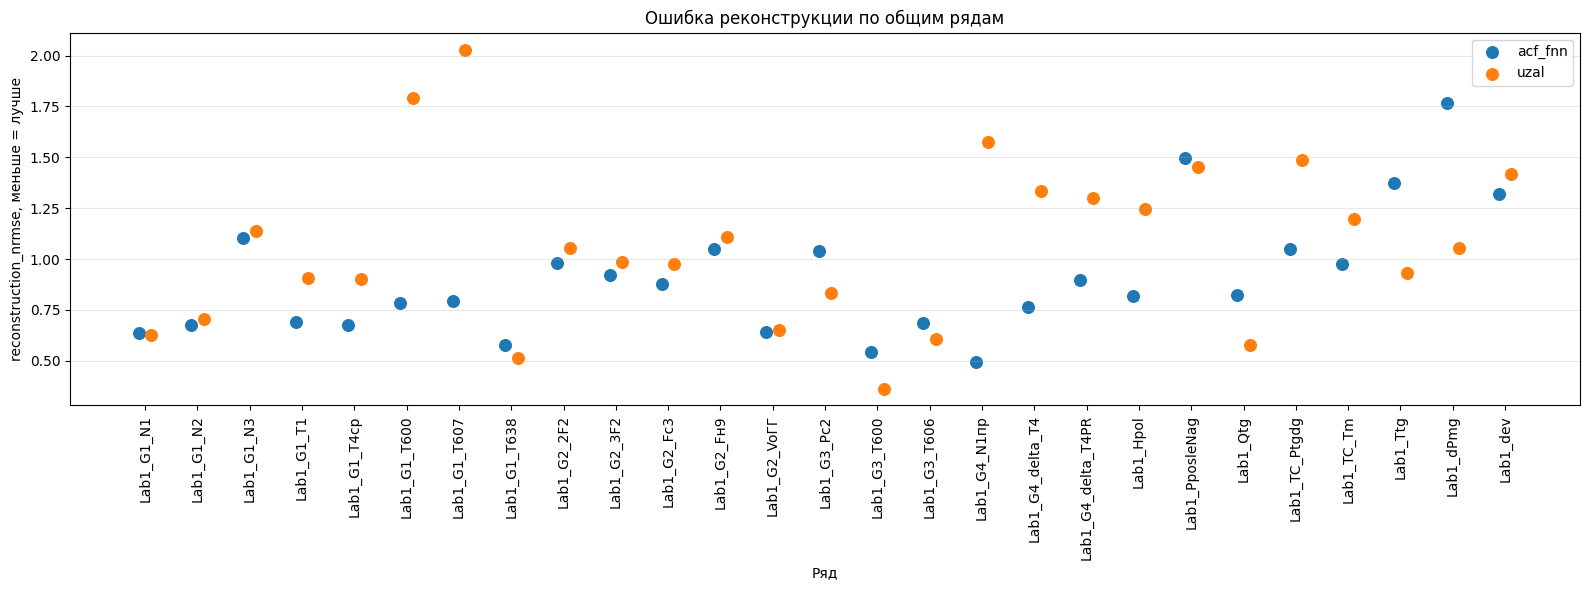

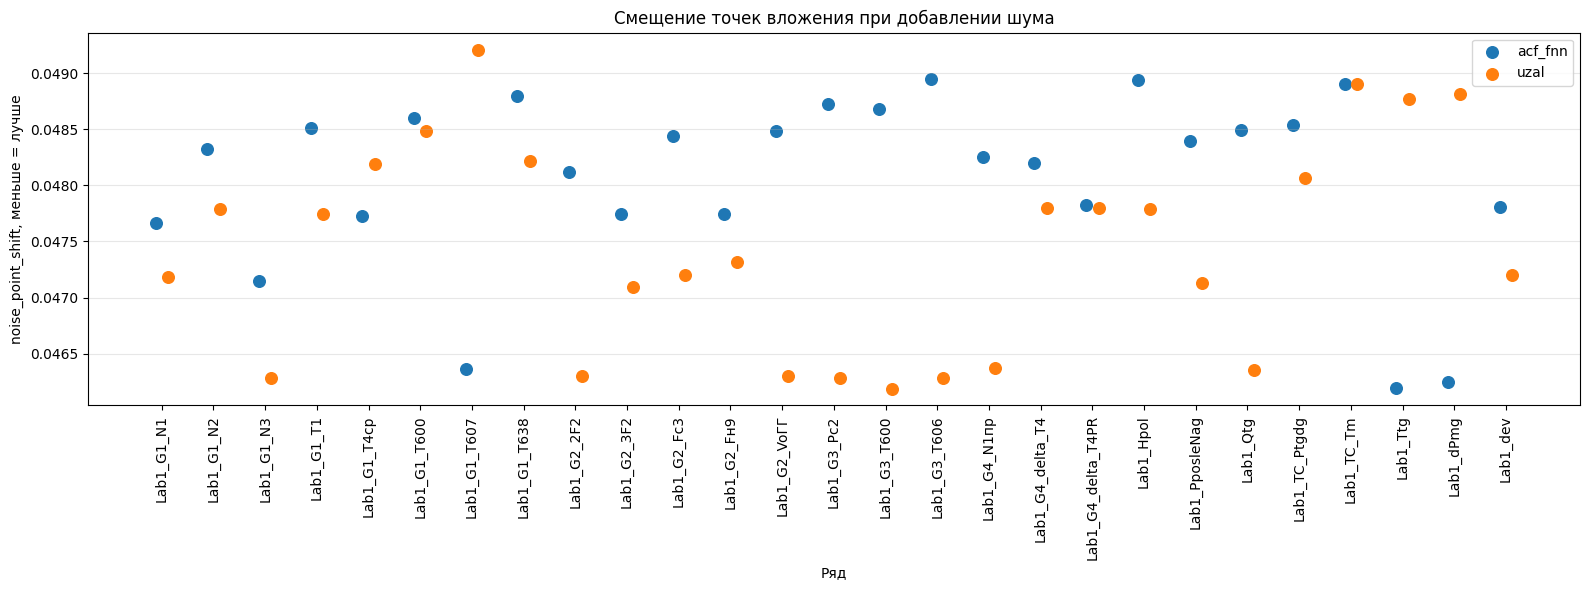

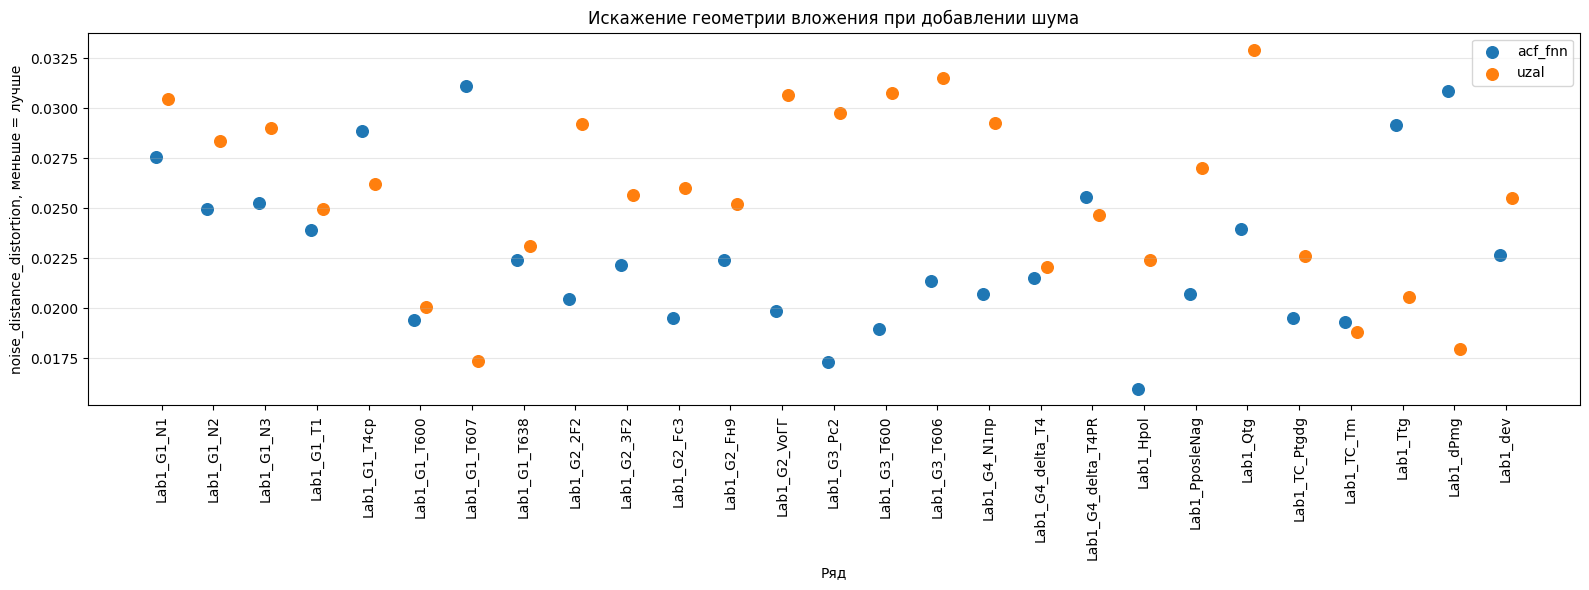

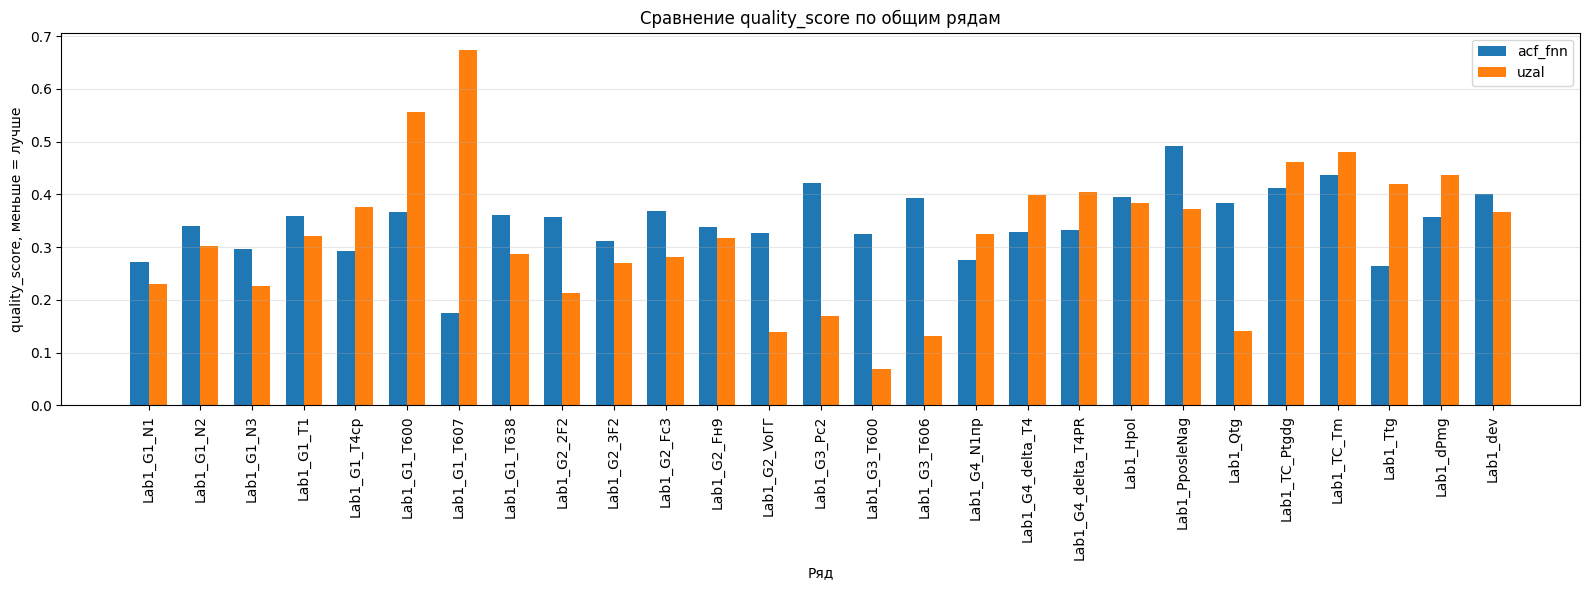

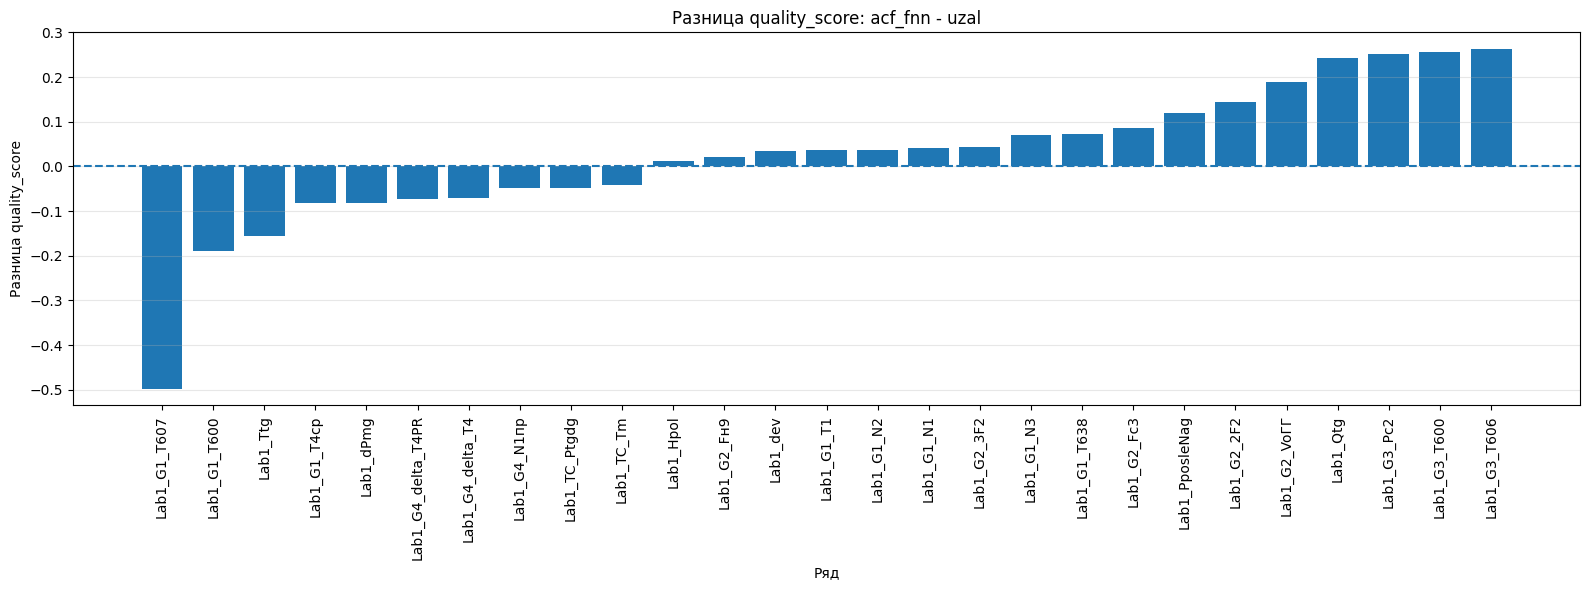

,column,best_method,quality_score_acf_fnn,quality_score_uzal,quality_score_diff_acf_fnn_minus_uzal,reconstruction_nrmse_acf_fnn,reconstruction_nrmse_uzal,noise_distance_distortion_acf_fnn,noise_distance_distortion_uzal
6,Lab1_G1_T607,acf_fnn,0.175838,0.673191,-0.497353,0.793957,2.030031,0.031130,0.017371
5,Lab1_G1_T600,acf_fnn,0.366866,0.557155,-0.190289,0.785661,1.790096,0.019414,0.020048
24,Lab1_Ttg,acf_fnn,0.264408,0.420032,-0.155624,1.375044,0.931668,0.029173,0.020549
4,Lab1_G1_T4ср,acf_fnn,0.292426,0.375504,-0.083077,0.675859,0.900011,0.028857,0.026207
25,Lab1_dPmg,acf_fnn,0.356699,0.437717,-0.081018,1.766551,1.055178,0.030889,0.017970
18,Lab1_G4_delta_T4PR,acf_fnn,0.332453,0.404605,-0.072152,0.896391,1.297872,0.025578,0.024671
17,Lab1_G4_delta_T4,acf_fnn,0.328236,0.399608,-0.071372,0.766497,1.333449,0.021486,0.022075
16,Lab1_G4_N1пр,acf_fnn,0.275838,0.325133,-0.049295,0.494465,1.575056,0.020692,0.029268
22,Lab1_TC_Ptgdg,acf_fnn,0.412922,0.462070,-0.049148,1.051203,1.484489,0.019500,0.022634
23,Lab1_TC_Tm,acf_fnn,0.436960,0.479551,-0.042591,0.973693,1.198231,0.019294,0.018806


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. ЧИТАЕМ РЕЗУЛЬТАТЫ
# =========================

full = pd.read_csv("embedding_quality_comparison_full.csv")

summary = pd.read_csv("embedding_quality_comparison_summary.csv")
best = pd.read_csv("embedding_quality_best_by_column.csv")

print("Количество строк по методам:")
print(full["method"].value_counts())

print("\nКоличество уникальных рядов по методам:")
print(full.groupby("method")["column"].nunique())

print("\nДубли по column + method:")
duplicates = (
    full.groupby(["column", "method"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)
display(duplicates)


# =========================
# 2. ОСТАВЛЯЕМ ТОЛЬКО СОВПАДАЮЩИЕ РЯДЫ
# =========================
# То есть только те ряды, где есть и acf_fnn, и uzal.

required_methods = {"acf_fnn", "uzal"}

methods_by_column = (
    full.groupby("column")["method"]
    .apply(lambda x: set(x))
)

common_columns = methods_by_column[
    methods_by_column.apply(lambda methods: required_methods.issubset(methods))
].index

full_common = full[full["column"].isin(common_columns)].copy()

# На всякий случай оставляем только нужные методы
full_common = full_common[full_common["method"].isin(required_methods)].copy()

print("\nВсего строк в исходном full:", len(full))
print("Общих рядов, где есть оба метода:", len(common_columns))
print("Строк после фильтрации:", len(full_common))

print("\nКоличество строк по методам после фильтрации:")
print(full_common["method"].value_counts())

print("\nКоличество уникальных рядов по методам после фильтрации:")
print(full_common.groupby("method")["column"].nunique())


# =========================
# 3. ТАБЛИЦА ТОЛЬКО ПО ОБЩИМ РЯДАМ
# =========================

cols_to_show = [
    "column",
    "method",
    "tau",
    "dimension",
    "uzal_cost",
    "reconstruction_nrmse",
    "noise_point_shift",
    "noise_distance_distortion",
    "quality_score"
]

comparison_table = (
    full_common[cols_to_show]
    .sort_values(["column", "method"])
    .reset_index(drop=True)
)

display(comparison_table)


# =========================
# 4. WIDE-ФОРМАТ ТОЛЬКО ПО ОБЩИМ РЯДАМ
# =========================

wide = full_common.pivot_table(
    index="column",
    columns="method",
    values=[
        "tau",
        "dimension",
        "reconstruction_nrmse",
        "noise_point_shift",
        "noise_distance_distortion",
        "quality_score"
    ],
    aggfunc="first"
)

wide.columns = [f"{metric}_{method}" for metric, method in wide.columns]
wide = wide.reset_index()

# Оставляем только строки, где реально есть обе оценки quality_score
wide = wide.dropna(
    subset=[
        "quality_score_acf_fnn",
        "quality_score_uzal"
    ]
).copy()

wide["quality_score_diff_acf_fnn_minus_uzal"] = (
    wide["quality_score_acf_fnn"] - wide["quality_score_uzal"]
)

wide["best_method"] = np.where(
    wide["quality_score_acf_fnn"] < wide["quality_score_uzal"],
    "acf_fnn",
    "uzal"
)

display(wide)


# =========================
# 5. СКОЛЬКО РАЗ КАКОЙ МЕТОД ЛУЧШЕ
# =========================

method_counts = wide["best_method"].value_counts()

display(method_counts.to_frame("wins"))

plt.figure(figsize=(6, 4))
plt.bar(method_counts.index, method_counts.values)
plt.title("Сколько раз каждый метод дал лучшее вложение")
plt.ylabel("Количество рядов")
plt.xlabel("Метод")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 6. ФУНКЦИЯ ДЛЯ ТОЧЕЧНЫХ ГРАФИКОВ
# =========================

def scatter_metric_by_method(df, metric, title, ylabel):
    plt.figure(figsize=(16, 6))

    # фиксируем порядок рядов
    columns_order = sorted(df["column"].unique())
    x_positions = {col: i for i, col in enumerate(columns_order)}

    # небольшой сдвиг точек, чтобы методы не накладывались друг на друга
    offsets = {
        "acf_fnn": -0.12,
        "uzal": 0.12
    }

    for method in ["acf_fnn", "uzal"]:
        method_df = df[df["method"] == method].copy()
        method_df = method_df.sort_values("column")

        x = [
            x_positions[col] + offsets.get(method, 0.0)
            for col in method_df["column"]
        ]

        plt.scatter(
            x,
            method_df[metric],
            label=method,
            s=70
        )

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Ряд")
    plt.xticks(
        range(len(columns_order)),
        columns_order,
        rotation=90
    )
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 7. QUALITY SCORE: ТОЛЬКО ТОЧКИ, ТОЛЬКО ОБЩИЕ РЯДЫ
# =========================

scatter_metric_by_method(
    full_common,
    metric="quality_score",
    title="Итоговый quality_score по общим рядам",
    ylabel="quality_score, меньше = лучше"
)


# =========================
# 8. RECONSTRUCTION NRMSE: ТОЛЬКО ТОЧКИ
# =========================

scatter_metric_by_method(
    full_common,
    metric="reconstruction_nrmse",
    title="Ошибка реконструкции по общим рядам",
    ylabel="reconstruction_nrmse, меньше = лучше"
)


# =========================
# 9. NOISE POINT SHIFT: ТОЛЬКО ТОЧКИ
# =========================

scatter_metric_by_method(
    full_common,
    metric="noise_point_shift",
    title="Смещение точек вложения при добавлении шума",
    ylabel="noise_point_shift, меньше = лучше"
)


# =========================
# 10. NOISE DISTANCE DISTORTION: ТОЛЬКО ТОЧКИ
# =========================

scatter_metric_by_method(
    full_common,
    metric="noise_distance_distortion",
    title="Искажение геометрии вложения при добавлении шума",
    ylabel="noise_distance_distortion, меньше = лучше"
)


# =========================
# 11. СТОЛБИКИ QUALITY SCORE ПО ОБЩИМ РЯДАМ
# =========================
# Это удобно, если хочется сравнить пары рядом.

wide_plot = wide.sort_values("column").copy()

x = np.arange(len(wide_plot))
width = 0.35

plt.figure(figsize=(16, 6))

plt.bar(
    x - width / 2,
    wide_plot["quality_score_acf_fnn"],
    width,
    label="acf_fnn"
)

plt.bar(
    x + width / 2,
    wide_plot["quality_score_uzal"],
    width,
    label="uzal"
)

plt.title("Сравнение quality_score по общим рядам")
plt.ylabel("quality_score, меньше = лучше")
plt.xlabel("Ряд")
plt.xticks(x, wide_plot["column"], rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# 12. РАЗНИЦА QUALITY SCORE
# =========================
# diff < 0  -> лучше acf_fnn
# diff > 0  -> лучше uzal

diff_plot = wide.sort_values("quality_score_diff_acf_fnn_minus_uzal").copy()

plt.figure(figsize=(16, 6))

plt.bar(
    diff_plot["column"],
    diff_plot["quality_score_diff_acf_fnn_minus_uzal"]
)

plt.axhline(0, linestyle="--")

plt.title("Разница quality_score: acf_fnn - uzal")
plt.ylabel("Разница quality_score")
plt.xlabel("Ряд")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 13. ТАБЛИЦА ЛУЧШИХ МЕТОДОВ ПО ОБЩИМ РЯДАМ
# =========================

best_table = wide[
    [
        "column",
        "best_method",
        "quality_score_acf_fnn",
        "quality_score_uzal",
        "quality_score_diff_acf_fnn_minus_uzal",
        "reconstruction_nrmse_acf_fnn",
        "reconstruction_nrmse_uzal",
        "noise_distance_distortion_acf_fnn",
        "noise_distance_distortion_uzal"
    ]
].copy()

best_table = best_table.sort_values(
    ["best_method", "quality_score_diff_acf_fnn_minus_uzal"]
)

display(best_table)